# SIH26158 - separate Full253 runtime-optimization experiment

This notebook preserves the completed `full253_after_geometry_fast` result as its reference and
runs one focused optimization candidate in a different Drive project. The candidate keeps all
253 sparse frames and the same 1920-pixel extracted imagery, then uses geometry-adaptive dense
anchors, at most ten source views per anchor, 1024-pixel PatchMatch, four iterations, and GPU
bundle adjustment when the installed COLMAP build supports it.

The reference took 52.62 minutes. The candidate is accepted only when runtime improves and all
structural quality guardrails pass. HF Drone has no independent surveyed surface truth, so this
experiment does not make a surface-accuracy claim.

Select **Runtime > Change runtime type > T4 GPU**. Run cells in order. Cell 2 restarts the runtime
once; continue from Cell 3 after that restart.

In [4]:
# CELL 1 - mount Drive and confirm the separate project, reference run, and GPU
import os, subprocess
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Optimization'
REFERENCE_OUTPUT = (
    '/content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/'
    'outputs/full253_geometry_ab/full253_after_geometry_fast'
)
assert os.path.isfile(f'{PROJECT_DIR}/requirements.txt'), (
    f'Extract the optimization ZIP to exactly MyDrive/SIH26158_HF_Drone_Optimization.'
)
assert os.path.isfile(f'{REFERENCE_OUTPUT}/run_report.json'), (
    'The completed Full253 fast reference run was not found in its original separate folder.'
)
gpu = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True,
)
assert gpu.returncode == 0, 'No NVIDIA GPU detected. Select a T4 GPU runtime.'
print('GPU:', gpu.stdout.strip())
print('Optimization project:', PROJECT_DIR)
print('Read-only comparison reference:', REFERENCE_OUTPUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4, 15360 MiB
Optimization project: /content/drive/MyDrive/SIH26158_HF_Drone_Optimization
Read-only comparison reference: /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/outputs/full253_geometry_ab/full253_after_geometry_fast


In [5]:
# CELL 2 - install Conda once; this intentionally restarts the runtime
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
# CELL 3 - install CUDA COLMAP and updated pipeline dependencies
import os, shutil, subprocess, sys
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Optimization'
REFERENCE_OUTPUT = (
    '/content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/'
    'outputs/full253_geometry_ab/full253_after_geometry_fast'
)
assert shutil.which('mamba'), 'Conda is missing. Run Cell 2 and wait for its restart.'
pin = '/usr/local/conda-meta/pinned'
if os.path.exists(pin):
    os.remove(pin)
subprocess.run(
    ['mamba', 'install', '-y', '-q', '-c', 'conda-forge', 'colmap', 'libfaiss', 'openimageio'],
    check=True,
)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{PROJECT_DIR}/requirements.txt'],
    check=True,
)
check = subprocess.run(['colmap', '-h'], capture_output=True, text=True, errors='replace')
header = (check.stdout or '') + (check.stderr or '')
print('\n'.join(header.splitlines()[:10]))
assert check.returncode == 0 and 'COLMAP' in header and 'CUDA' in header
assert 'pose_prior_mapper' in header, 'Current COLMAP pose-prior mapper is required.'
subprocess.run(
    [sys.executable, '-m', 'unittest', 'discover', '-s', 'tests', '-v'],
    cwd=PROJECT_DIR, check=True,
)
print('Installation and tests complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COLMAP 4.2.0 (Commit Unknown on Unknown with CUDA)
Usage:
  colmap [command] [options]
Documentation:
  https://colmap.github.io/
Example usage:
  colmap help [ -h, --help ]
  colmap gui
  colmap gui -h [ --help ]
  colmap automatic_reconstructor -h [ --help ]
Installation and tests complete.


In [2]:
# CELL 4 - download and normalize the same HF Drone source
import json, os, subprocess, sys

DATA_DIR = '/content/hf_drone_dataset'
PREPARED_DIR = '/content/hf_drone_prepared'
VIDEO = f'{DATA_DIR}/20240629164410_0023_D.mp4'
TELEMETRY = f'{PREPARED_DIR}/hf_drone_telemetry.csv'
env = os.environ.copy()
env['PYTHONPATH'] = PROJECT_DIR + os.pathsep + env.get('PYTHONPATH', '')
subprocess.run([
    sys.executable, '-m', 'sih_drone_pipeline.dataset',
    '--dataset', 'hf-drone', '--download-dir', DATA_DIR, '--output', PREPARED_DIR,
], cwd=PROJECT_DIR, env=env, check=True)
manifest = json.load(open(f'{PREPARED_DIR}/dataset_manifest.json'))
print(json.dumps({
    'telemetry_samples': manifest['telemetry_samples'],
    'telemetry_duration_s': manifest['telemetry_duration_s'],
    'recording_segments_found': manifest['recording_segments_found'],
    'gps_satellites_median': manifest['gps_satellites_median'],
}, indent=2))

{
  "telemetry_samples": 2525,
  "telemetry_duration_s": 252.4,
  "recording_segments_found": 2,
  "gps_satellites_median": 25.0
}


In [3]:
# CELL 5 - configure the focused candidate; reference output remains untouched
import json, os, subprocess

RUN_NAME = 'full253_opt_adaptive_1024_i4_s10'
EXPERIMENT_ROOT = f'{PROJECT_DIR}/outputs/adaptive_mvs_optimization'
OUTPUT = f'{EXPERIMENT_ROOT}/{RUN_NAME}'
WORKSPACE = f'/content/sih26158_{RUN_NAME}'
TARGET_FRAMES = 253
MAX_WIDTH = 1920
DSM_RESOLUTION_M = 0.5
RESET_WORKSPACE = True
REUSE_COMPLETED_OUTPUT = True
CLEAN_WORKSPACE_AFTER_RUN = True
os.makedirs(EXPERIMENT_ROOT, exist_ok=True)

reference = json.load(open(f'{REFERENCE_OUTPUT}/run_report.json'))
print('Reference runtime (min):', round(reference['wall_clock_seconds'] / 60, 2))
print('Reference registered images:', reference['sparse_metrics']['registered_images'])
print('Reference point count:', reference['products']['point_count'])
mapper_help = subprocess.run(
    ['colmap', 'pose_prior_mapper', '--help'], capture_output=True, text=True, errors='replace'
)
gpu_ba_lines = [line.strip() for line in (mapper_help.stdout + mapper_help.stderr).splitlines()
                if 'ba_use_gpu' in line]
print('GPU BA option detected:', gpu_ba_lines or 'not exposed; pipeline will fall back safely')
print('New output:', OUTPUT)

Reference runtime (min): 52.62
Reference registered images: 207
Reference point count: 736918
GPU BA option detected: ['--Mapper.ba_use_gpu arg (=0)']
New output: /content/drive/MyDrive/SIH26158_HF_Drone_Optimization/outputs/adaptive_mvs_optimization/full253_opt_adaptive_1024_i4_s10


In [5]:
# CELL 6 - run or resume the optimized candidate
import os, shutil, subprocess, sys, time

env = os.environ.copy()
env['PYTHONPATH'] = PROJECT_DIR + os.pathsep + env.get('PYTHONPATH', '')
if REUSE_COMPLETED_OUTPUT and os.path.isfile(f'{OUTPUT}/run_report.json'):
    existing = subprocess.run(
        [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', OUTPUT],
        cwd=PROJECT_DIR, env=env,
    )
    if existing.returncode == 0:
        print('Reusing verified completed optimization run:', OUTPUT)
        RUN_COMPLETE = True
    else:
        RUN_COMPLETE = False
else:
    RUN_COMPLETE = False

if not RUN_COMPLETE:
    os.makedirs(OUTPUT, exist_ok=True)
    if RESET_WORKSPACE and os.path.isdir(WORKSPACE):
        shutil.rmtree(WORKSPACE)
    assert subprocess.run([
        sys.executable, '-m', 'sih_drone_pipeline', 'preflight',
        '--video', VIDEO, '--telemetry', TELEMETRY, '--workspace', WORKSPACE,
        '--output', f'{OUTPUT}/preflight.json',
    ], cwd=PROJECT_DIR, env=env).returncode == 0
    command = [
        sys.executable, '-m', 'sih_drone_pipeline', 'run',
        '--video', VIDEO, '--telemetry', TELEMETRY,
        '--workspace', WORKSPACE, '--output', OUTPUT,
        '--quality', 'draft', '--target-frames', str(TARGET_FRAMES),
        '--max-width', str(MAX_WIDTH), '--dsm-resolution', str(DSM_RESOLUTION_M),
        '--keyframe-mode', 'geometry', '--mapper', 'pose-prior',
        '--gps-prior-std-m', '5.0', '--mapper-ba-gpu',
        '--dense-frame-stride', '2', '--dense-anchor-mode', 'adaptive',
        '--dense-source-images', '10', '--dense-max-image-size', '1024',
        '--dense-num-iterations', '4', '--dense-num-samples', '15',
    ]
    stop_file = '/content/sih26158_optimization_gpu.stop'
    if os.path.exists(stop_file):
        os.remove(stop_file)
    monitor = subprocess.Popen([
        sys.executable, '-m', 'sih_drone_pipeline.gpu_monitor',
        '--output', f'{OUTPUT}/gpu_usage.csv', '--stop-file', stop_file,
    ], cwd=PROJECT_DIR, env=env)
    print('Running:', ' '.join(command))
    started = time.time()
    try:
        result = subprocess.run(command, cwd=PROJECT_DIR, env=env)
    finally:
        open(stop_file, 'w').close()
        monitor.wait(timeout=20)
        if os.path.isdir(f'{WORKSPACE}/logs'):
            shutil.copytree(f'{WORKSPACE}/logs', f'{OUTPUT}/logs', dirs_exist_ok=True)
        partial = f'{WORKSPACE}/run_report.partial.json'
        if os.path.isfile(partial):
            shutil.copy2(partial, f'{OUTPUT}/run_report.partial.json')
    print('Candidate runtime (min):', round((time.time() - started) / 60, 2))
    assert result.returncode == 0, 'Optimization run failed; inspect OUTPUT/logs.'
    shutil.copy2(f'{PREPARED_DIR}/dataset_manifest.json', f'{OUTPUT}/dataset_manifest.json')
    assert subprocess.run(
        [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', OUTPUT],
        cwd=PROJECT_DIR, env=env,
    ).returncode == 0
    if CLEAN_WORKSPACE_AFTER_RUN and os.path.isdir(WORKSPACE):
        shutil.rmtree(WORKSPACE)

Running: /usr/bin/python3.real -m sih_drone_pipeline run --video /content/hf_drone_dataset/20240629164410_0023_D.mp4 --telemetry /content/hf_drone_prepared/hf_drone_telemetry.csv --workspace /content/sih26158_full253_opt_adaptive_1024_i4_s10 --output /content/drive/MyDrive/SIH26158_HF_Drone_Optimization/outputs/adaptive_mvs_optimization/full253_opt_adaptive_1024_i4_s10 --quality draft --target-frames 253 --max-width 1920 --dsm-resolution 0.5 --keyframe-mode geometry --mapper pose-prior --gps-prior-std-m 5.0 --mapper-ba-gpu --dense-frame-stride 2 --dense-anchor-mode adaptive --dense-source-images 10 --dense-max-image-size 1024 --dense-num-iterations 4 --dense-num-samples 15
Candidate runtime (min): 40.95


In [6]:
# CELL 7 - compare runtime, stages, geometry products, and acceptance gates
import json, subprocess, sys
import pandas as pd

comparison_path = f'{EXPERIMENT_ROOT}/optimization_comparison.json'
assert subprocess.run([
    sys.executable, '-m', 'sih_drone_pipeline', 'compare',
    '--before', REFERENCE_OUTPUT, '--after', OUTPUT, '--output', comparison_path,
], cwd=PROJECT_DIR, env=env).returncode == 0
comparison = json.load(open(comparison_path))
rows = []
for metric, values in comparison['metrics'].items():
    rows.append({
        'metric': metric, 'reference': values['before'], 'candidate': values['after'],
        'change_percent': values['change_percent'],
    })
metrics = pd.DataFrame(rows)
display(metrics)
metrics.to_csv(f'{EXPERIMENT_ROOT}/optimization_metrics.csv', index=False)

reference = json.load(open(f'{REFERENCE_OUTPUT}/run_report.json'))
candidate = json.load(open(f'{OUTPUT}/run_report.json'))
stage_names = sorted(set(reference.get('stages', {})) | set(candidate.get('stages', {})))
stage_rows = []
for name in stage_names:
    before = reference.get('stages', {}).get(name, {}).get('seconds')
    after = candidate.get('stages', {}).get(name, {}).get('seconds')
    stage_rows.append({
        'stage': name,
        'reference_min': round(before / 60, 2) if before is not None else None,
        'candidate_min': round(after / 60, 2) if after is not None else None,
    })
stages = pd.DataFrame(stage_rows)
display(stages)
stages.to_csv(f'{EXPERIMENT_ROOT}/optimization_stage_times.csv', index=False)

decision = {
    'reference_runtime_min': round(reference['wall_clock_seconds'] / 60, 2),
    'candidate_runtime_min': round(candidate['wall_clock_seconds'] / 60, 2),
    'speedup': comparison['speedup'],
    'quality_guardrails': comparison['quality_guardrails'],
    'passes_quality_guardrails': comparison['passes_quality_guardrails'],
    'recommended': bool(comparison['speedup'] and comparison['speedup'] > 1
                        and comparison['passes_quality_guardrails']),
    'surface_accuracy': comparison['surface_accuracy_note'],
    'mapper_ba_gpu': candidate.get('mapper_ba_gpu'),
    'dense_reference_selection': candidate.get('dense_reference_selection'),
}
json.dump(decision, open(f'{EXPERIMENT_ROOT}/optimization_decision.json', 'w'), indent=2)
print(json.dumps(decision, indent=2))

,metric,reference,candidate,change_percent
0,wall_clock_seconds,3157.440000,2452.510000,-22.325998
1,input_frames,253.000000,253.000000,0.000000
2,registered_images,207.000000,207.000000,0.000000
3,registration_percent,81.820000,81.820000,0.000000
4,reprojection_error_px,0.452920,0.452978,0.012806
5,gps_alignment_rmse_m,1.824624,1.826534,0.104642
6,point_count,736918.000000,537664.000000,-27.038829
7,dsm_valid_fraction,0.116724,0.141313,21.065868
8,mesh_vertices,221378.000000,171956.000000,-22.324712
9,mesh_faces,441821.000000,342394.000000,-22.503910


,stage,reference_min,candidate_min
0,aligned_model_text_export,0.12,0.09
1,delaunay_meshing,5.69,3.51
2,dense_stereo,16.08,8.74
3,feature_extraction,0.26,0.25
4,gps_alignment,0.01,0.02
5,image_undistortion,0.54,0.54
6,mesh_cleanup,0.04,0.02
7,mesh_texturing,2.12,1.68
8,sequential_matching,2.25,2.32
9,sparse_analysis,0.01,0.02


{
  "reference_runtime_min": 52.62,
  "candidate_runtime_min": 40.88,
  "speedup": 1.2874320594003694,
  "quality_guardrails": {
    "runtime_improved": true,
    "registration_drop_at_most_1_point": true,
    "reprojection_increase_at_most_0_03_px": true,
    "gps_rmse_increase_at_most_0_15_m": true,
    "point_count_retains_75_percent": false,
    "dsm_coverage_retains_95_percent": true,
    "mesh_components_increase_at_most_3": true
  },
  "passes_quality_guardrails": false,
  "recommended": false,
  "surface_accuracy": "NOT EVALUATED: both runs need the same independent surveyed checkpoints; reprojection and GPS residual do not prove surface accuracy.",
  "mapper_ba_gpu": {
    "requested": true,
    "supported": true,
    "enabled": true,
    "option": "--Mapper.ba_use_gpu"
  },
  "dense_reference_selection": {
    "stride": 2,
    "selection_mode": "adaptive",
    "max_source_images": 10,
    "original_references": 207,
    "selected_references": 104
  }
}


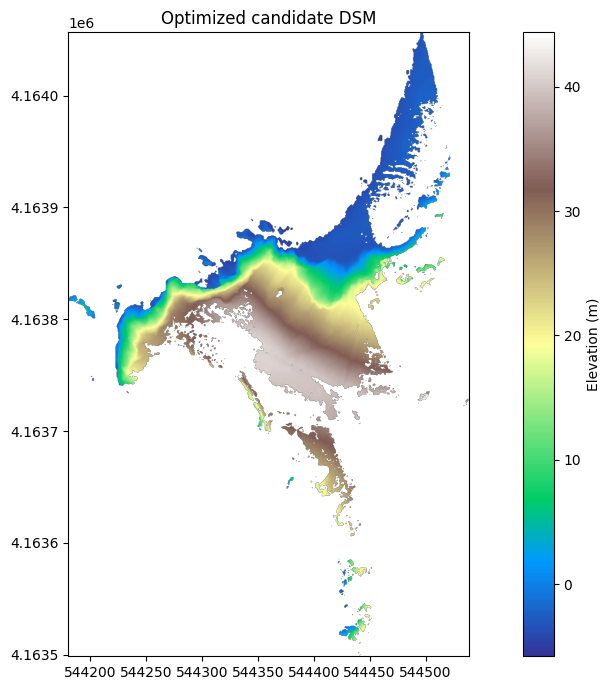

In [7]:
# CELL 8 - inspect the candidate DSM and point cloud
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import rasterio
import trimesh

with rasterio.open(f'{OUTPUT}/dsm.tif') as dataset:
    dsm = dataset.read(1, masked=True)
    bounds = dataset.bounds
plt.figure(figsize=(11, 7))
plt.imshow(dsm, cmap='terrain', extent=[bounds.left, bounds.right, bounds.bottom, bounds.top], origin='upper')
plt.colorbar(label='Elevation (m)')
plt.title('Optimized candidate DSM')
plt.tight_layout(); plt.show()

cloud = trimesh.load(f'{OUTPUT}/point_cloud.ply', process=False)
vertices = np.asarray(cloud.vertices)
rng = np.random.default_rng(26158)
sample = rng.choice(len(vertices), min(50000, len(vertices)), replace=False)
points = vertices[sample]
figure = go.Figure(go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers',
    marker={'size': 1.2, 'color': points[:, 2], 'colorscale': 'Viridis'},
))
figure.update_layout(title='Optimized candidate point cloud', scene={'aspectmode': 'data'}, height=700)
figure.write_html(f'{OUTPUT}/optimization_point_cloud_preview.html', include_plotlyjs=True)
figure.show()

In [8]:
# CELL 9 - create a compact evidence archive; large models stay in Drive
import os, shutil

evidence = f'{EXPERIMENT_ROOT}/optimization_evidence'
os.makedirs(evidence, exist_ok=True)
for path in [
    comparison_path,
    f'{EXPERIMENT_ROOT}/optimization_comparison.md',
    f'{EXPERIMENT_ROOT}/optimization_metrics.csv',
    f'{EXPERIMENT_ROOT}/optimization_stage_times.csv',
    f'{EXPERIMENT_ROOT}/optimization_decision.json',
    f'{OUTPUT}/run_report.json',
    f'{OUTPUT}/verification_report.json',
    f'{OUTPUT}/frames.csv',
    f'{OUTPUT}/frames.selection.json',
    f'{OUTPUT}/gpu_usage.csv',
    f'{OUTPUT}/dataset_manifest.json',
]:
    if os.path.isfile(path):
        shutil.copy2(path, f'{evidence}/{os.path.basename(path)}')
archive = shutil.make_archive(f'{EXPERIMENT_ROOT}/optimization_evidence', 'zip', evidence)
print('Evidence archive:', archive)
print('Full candidate products:', OUTPUT)

Evidence archive: /content/drive/MyDrive/SIH26158_HF_Drone_Optimization/outputs/adaptive_mvs_optimization/optimization_evidence.zip
Full candidate products: /content/drive/MyDrive/SIH26158_HF_Drone_Optimization/outputs/adaptive_mvs_optimization/full253_opt_adaptive_1024_i4_s10


## Decision rule

Adopt the candidate only when `optimization_decision.json` reports `recommended: true`.
The guardrails require improved runtime, no more than a one-point registration loss, no more
than 0.03 px additional reprojection error, no more than 0.15 m additional GPS RMSE, at least
75% of the reference points, at least 95% of reference DSM coverage, and no more than three
additional mesh components. These are comparative structural gates, not surveyed accuracy.